# 8-Queens Las Vegas Algorithm Analysis

This notebook analyzes the performance data generated by the `EightQueensBenchmark.java` tool.

**Objective:** Determine the optimal value of $k$ (number of randomly placed queens) that minimizes execution time while keeping restart counts manageable.

### Instructions
1. Run the Java benchmark tool locally to generate `benchmark_results.csv`.
2. Run the code cells below. The first cell will prompt you to upload that CSV file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("Libraries loaded.")

Libraries loaded.


### 1. Upload Data
Run this cell to upload your `benchmark_results.csv` file.

In [2]:
try:
    from google.colab import files
    print("Please upload 'benchmark_results.csv'...")
    uploaded = files.upload()
    
    # Get the filename (assuming only one file uploaded)
    filename = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"Successfully loaded {len(df)} rows from {filename}.")
    
except ImportError:
    # Fallback for local Jupyter execution (not Colab)
    try:
        filename = 'benchmark_results.csv'
        df = pd.read_csv(filename)
        print(f"Successfully loaded {len(df)} rows from local file.")
    except FileNotFoundError:
        print("Error: 'benchmark_results.csv' not found. Please upload or place the file in the working directory.")

Successfully loaded 90000 rows from local file.


### 2. Preprocessing
Convert time from nanoseconds to milliseconds for easier reading.

In [3]:
if 'df' in locals():
    # Convert ns to ms
    df['time_ms'] = df['time_ns'] / 1_000_000.0
    
    # Display first few rows
    display(df.head())
    
    # Basic stats
    print("\nDataset Overview:")
    print(df.info())

,k,time_ns,restarts,time_ms
0,0,2599,0,0.002599
1,0,7700,0,0.007700
2,0,5501,0,0.005501
3,0,3099,0,0.003099
4,0,2499,0,0.002499



Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   k         90000 non-null  int64  
 1   time_ns   90000 non-null  int64  
 2   restarts  90000 non-null  int64  
 3   time_ms   90000 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 2.7 MB
None


### 3. Execution Time Distribution (Box Plot)
This visualization shows the spread of execution times for each configuration ($k$).
* **Box:** Interquartile range (middle 50% of data).
* **Line:** Median time.
* **Note:** $k=0$ represents Deterministic Backtracking.

C:\Users\crafts\AppData\Local\Temp\ipykernel_48980\596634112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='k', y='time_ms', data=df, showfliers=False, palette="Blues")


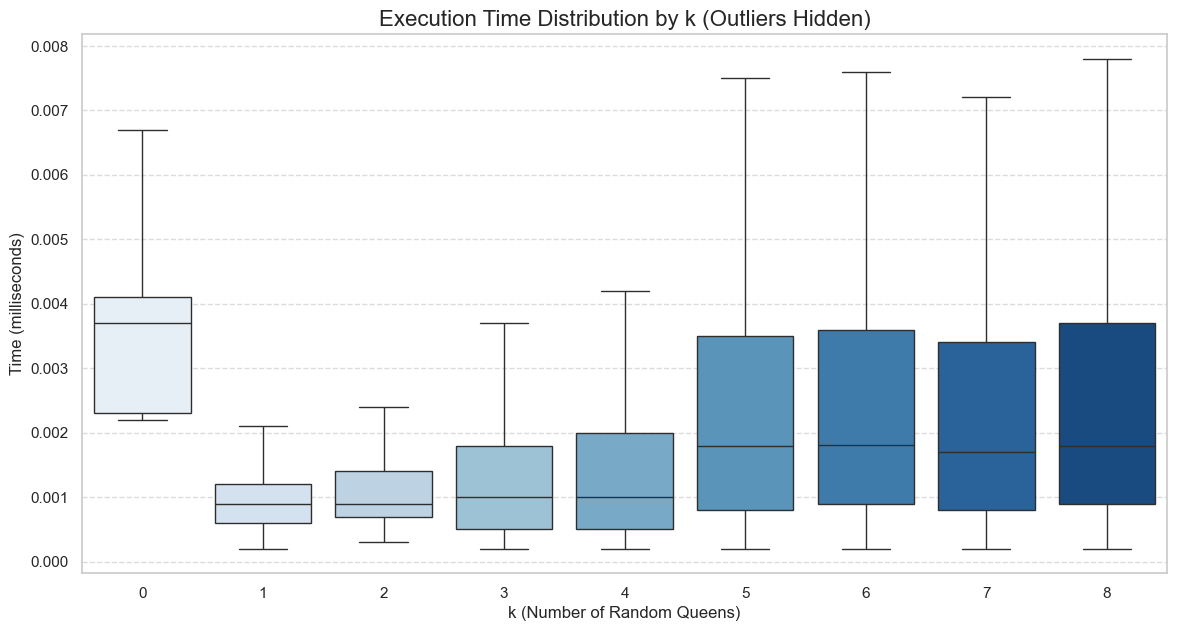

In [4]:
if 'df' in locals():
    plt.figure(figsize=(14, 7))
    
    # Create Boxplot
    # showfliers=False hides extreme outliers to keep the scale readable
    sns.boxplot(x='k', y='time_ms', data=df, showfliers=False, palette="Blues")
    
    plt.title('Execution Time Distribution by k (Outliers Hidden)', fontsize=16)
    plt.ylabel('Time (milliseconds)', fontsize=12)
    plt.xlabel('k (Number of Random Queens)', fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    plt.show()

### 4. Trade-off Analysis: Speed vs. Restarts
Here we overlay two metrics to find the "Sweet Spot":
1.  **Average Time (Blue Line):** How fast the algorithm runs on average.
2.  **Average Restarts (Red Dashed Line):** How often the algorithm hits a dead end and has to restart.

We are looking for the lowest point on the Blue line before the Red line spikes.

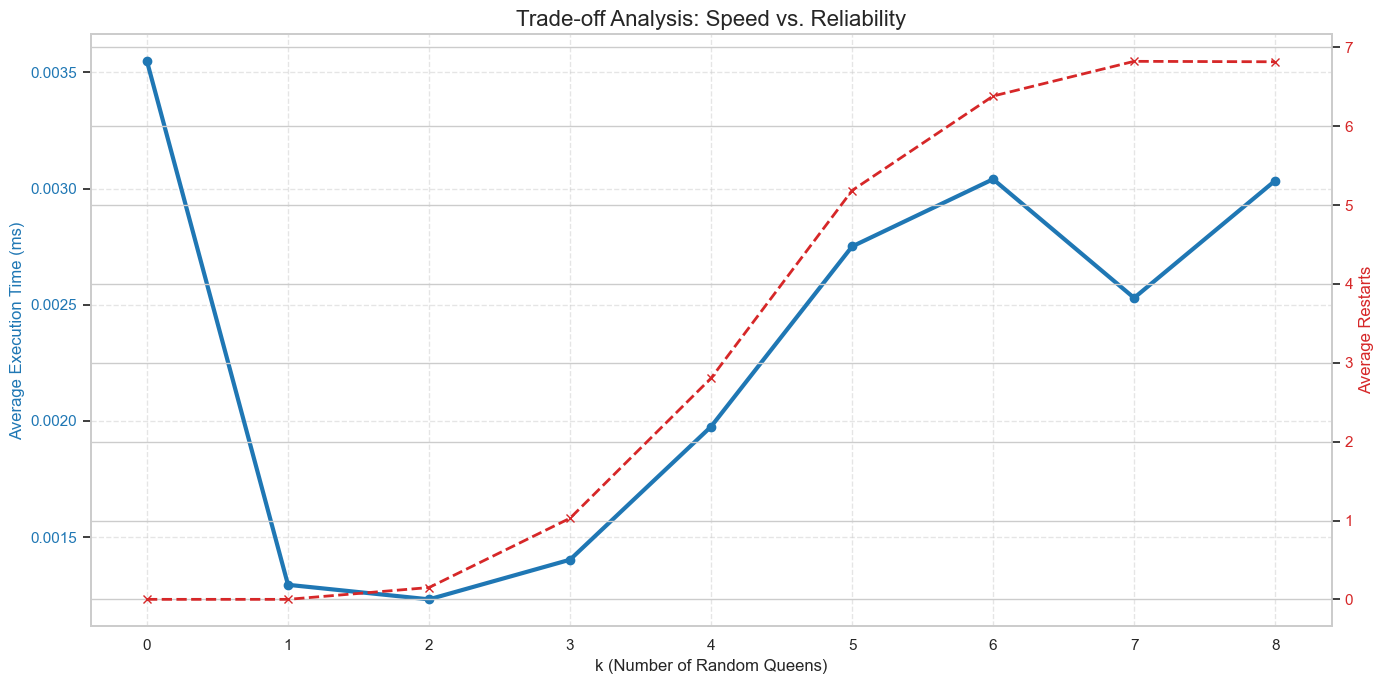

In [5]:
if 'df' in locals():
    # Aggregate data
    summary = df.groupby('k').agg({
        'time_ms': 'mean',
        'restarts': 'mean'
    }).reset_index()

    # Create Dual-Axis Plot
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot Time (Left Y-Axis)
    color_time = 'tab:blue'
    ax1.set_xlabel('k (Number of Random Queens)', fontsize=12)
    ax1.set_ylabel('Average Execution Time (ms)', color=color_time, fontsize=12)
    ax1.plot(summary['k'], summary['time_ms'], color=color_time, marker='o', linewidth=3, label='Avg Time')
    ax1.tick_params(axis='y', labelcolor=color_time)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Create Right Y-Axis for Restarts
    ax2 = ax1.twinx()
    color_restart = 'tab:red'
    ax2.set_ylabel('Average Restarts', color=color_restart, fontsize=12)
    ax2.plot(summary['k'], summary['restarts'], color=color_restart, marker='x', linestyle='--', linewidth=2, label='Avg Restarts')
    ax2.tick_params(axis='y', labelcolor=color_restart)

    # Title and Layout
    plt.title('Trade-off Analysis: Speed vs. Reliability', fontsize=16)
    fig.tight_layout()
    plt.show()

### 5. Summary Statistics Table

In [6]:
if 'df' in locals():
    # Calculate detailed stats
    stats_table = df.groupby('k')['time_ms'].describe()[['mean', 'std', 'min', 'max']]
    stats_table['avg_restarts'] = df.groupby('k')['restarts'].mean()

    # Formatting
    pd.options.display.float_format = '{:,.3f}'.format
    print("Summary Statistics (Time in ms):")
    display(stats_table)

Summary Statistics (Time in ms):


,mean,std,min,max,avg_restarts
k,,,,,
0,0.004,0.003,0.002,0.195,0.000
1,0.001,0.005,0.000,0.250,0.000
2,0.001,0.002,0.000,0.148,0.150
3,0.001,0.001,0.000,0.032,1.029
4,0.002,0.040,0.000,4.045,2.805
5,0.003,0.003,0.000,0.128,5.185
6,0.003,0.024,0.000,2.376,6.383
7,0.003,0.003,0.000,0.037,6.824
8,0.003,0.004,0.000,0.144,6.818
